In [39]:
# importing libraries 
import pandas as pd # reading csv files and data handling
import numpy as np # for performing numerical operation
import matplotlib.pyplot as plt # for graphical visaulization

In [2]:
# loading dataset
df = pd.read_csv(r"C:\Users\rasika\Downloads\exchange_rate.csv")
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [3]:
# dataset Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [4]:
# Summary statistics
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [5]:
# converting date of object datatype to numeric datatype
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')

In [6]:
# Settting date column as index
df.set_index('date', inplace = True)
df

,Ex_rate
date,
1990-01-01,0.785500
1990-01-02,0.781800
1990-01-03,0.786700
1990-01-04,0.786000
1990-01-05,0.784900
...,...
2010-10-06,0.718494
2010-10-07,0.721839
2010-10-08,0.723197


In [7]:
# Checking for missing values
df.isnull().sum()

Ex_rate    0
dtype: int64

In [8]:
# checking for duplicates
df.duplicated().sum()

np.int64(2258)

In [9]:
# removing duplicates
df.drop_duplicates(inplace = True)

In [10]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

### Time series plot

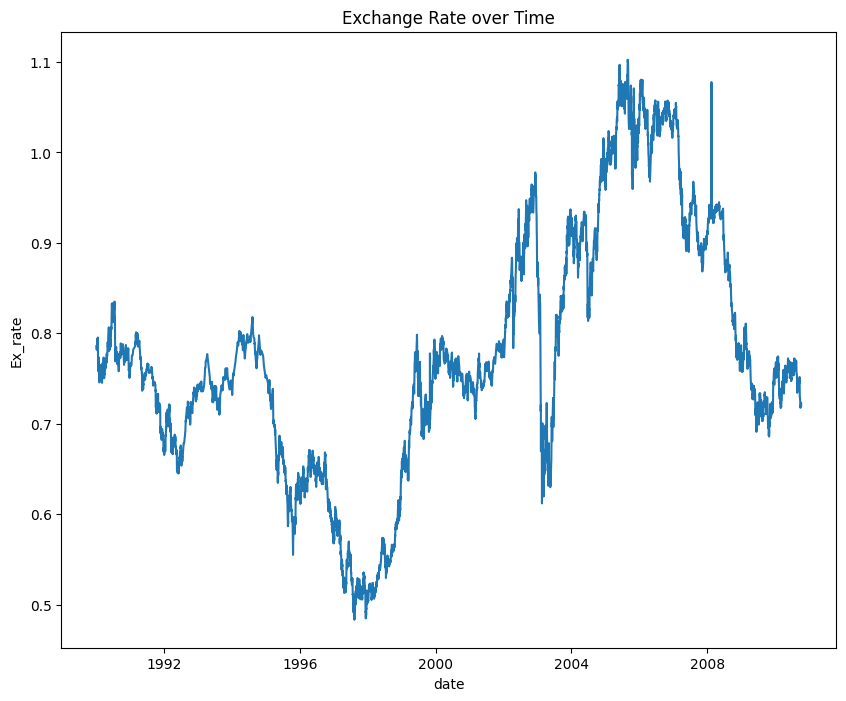

In [14]:
plt.figure(figsize = (10, 8))
plt.plot(df.iloc[:, 0])
plt.title('Exchange Rate over Time')
plt.xlabel('date')
plt.ylabel('Ex_rate')
plt.show()

In [42]:
# Performs the Augmented Dickey-Fuller (ADF) test to check stationarity of the time series
from statsmodels.tsa.stattools import adfuller
# Creates ACF and PACF plots for identifying ARIMA model parameters (p and q)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Imports the ARIMA model for time series forecasting
from statsmodels.tsa.arima.model import ARIMA
# Imports Exponential Smoothing model for forecasting trends and seasonality
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Imports evaluation metrics to measure forecasting accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Suppresses warning messages to keep the output clean
import warnings
warnings.filterwarnings('ignore')

In [15]:
# ADF to check similarity
result = adfuller(df['Ex_rate'])

print("ADF Statistic:", result[0])
print("P-value:", result[1])

ADF Statistic: -1.4941908583137475
P-value: 0.5363830559037672


##### p-value(0.53) > 0.05 
data is non-stationary

In [20]:
# Differencing - coverting non-stationary data to stationary
df_diff = df['Ex_rate'].diff().dropna()
adf_result_diff = adfuller(df_diff)
print("ADF Statistic:", adf_result_diff[0])
print("P-value:", adf_result_diff[1])

ADF Statistic: -84.04895592713106
P-value: 0.0


##### p-value(0.0) < 0.05
data is stationary

In [21]:
# Train-test split
# keeping latest data for testing
train_size = int(len(df)*0.8)

train = df['Ex_rate'][:train_size]
test = df['Ex_rate'][train_size:]

<Figure size 800x600 with 0 Axes>

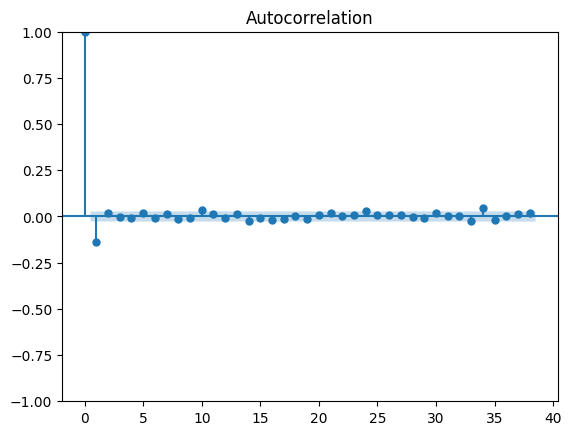

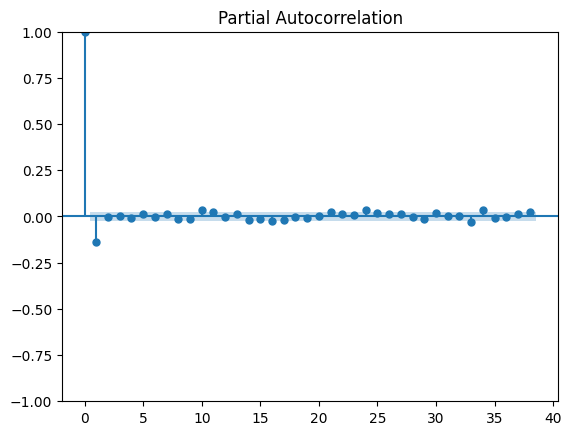

In [26]:
# AutoCorrelationFuction(ACF)
plt.figure(figsize = (8, 6))
plot_acf(df_diff)
plt.show()

# PartialAutoCorrelationFunction(PACF)
plot_pacf(df_diff)
plt.show()

##### p = 1, q = 1, d=0
Model ARIMA(1, 0, 1)

In [29]:
# Fit ARIMA model
model = ARIMA(train, order=(1,0,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 4264
Model:                 ARIMA(1, 0, 1)   Log Likelihood               15195.159
Date:                Wed, 10 Jun 2026   AIC                         -30382.318
Time:                        22:31:33   BIC                         -30356.887
Sample:                             0   HQIC                        -30373.333
                               - 4264                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7664      0.195      3.929      0.000       0.384       1.149
ar.L1          0.9995      0.001   1768.865      0.000       0.998       1.001
ma.L1         -0.0720      0.007    -10.356      0.0

In [30]:
# Forecasting
forecast = model_fit.forecast(steps=len(test))

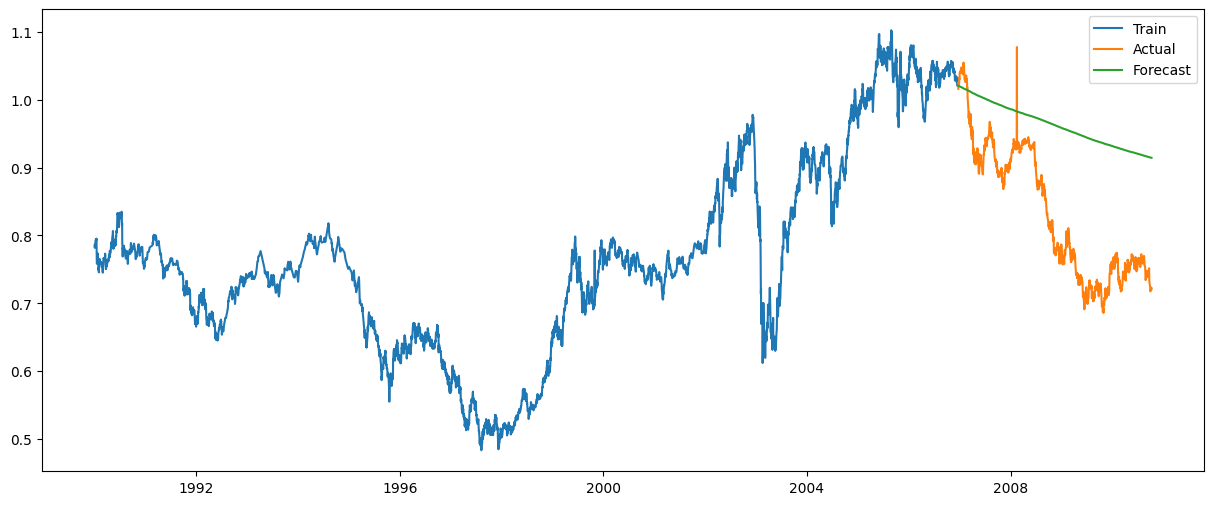

In [31]:
plt.figure(figsize=(15,6))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.show()

In [32]:
# Residual Analysis
residuals = model_fit.resid

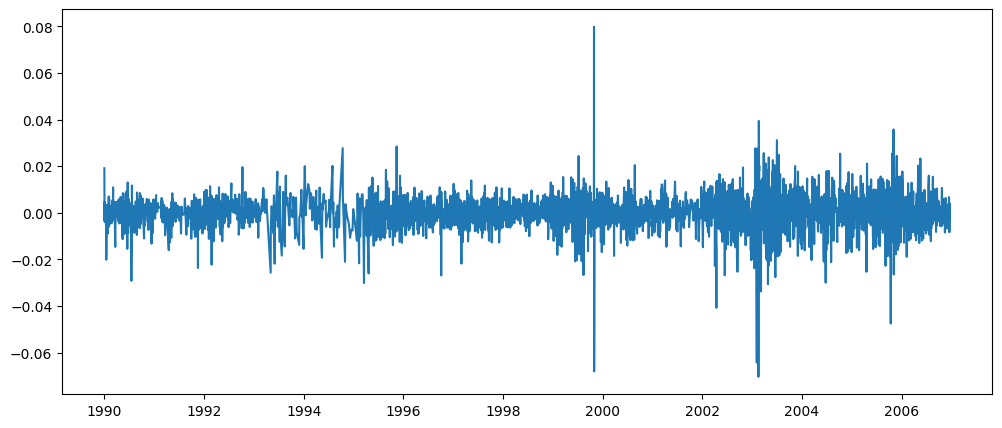

In [33]:
plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.show()

In [34]:
# Exponential Smoothing
es_model = ExponentialSmoothing(train, trend='add',  seasonal=None).fit()

In [35]:
# Forecasting
es_forecast = es_model.forecast(len(test))

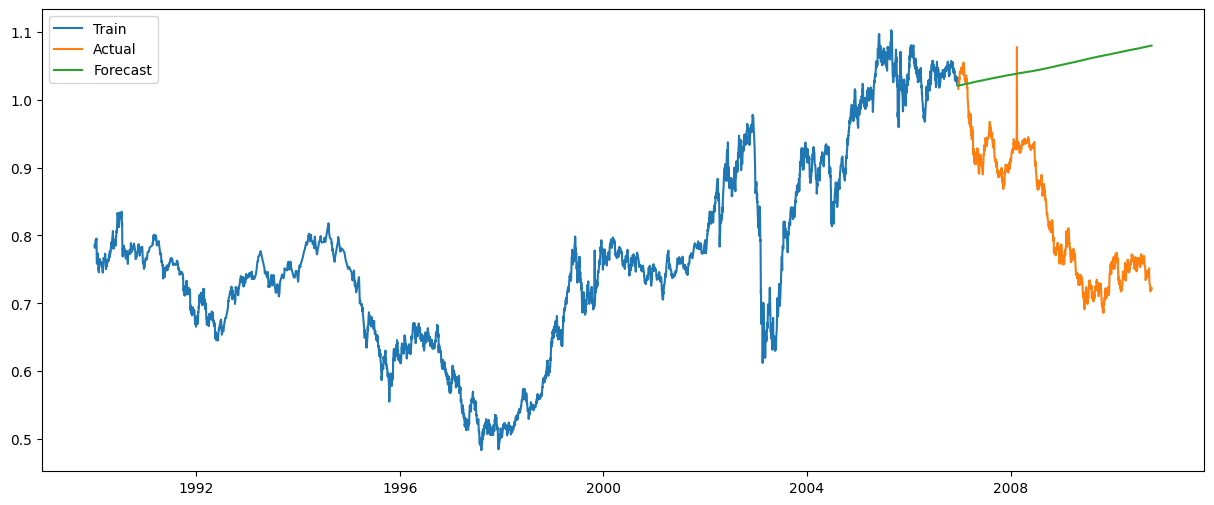

In [36]:
plt.figure(figsize=(15,6))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, es_forecast, label='Forecast')

plt.legend()
plt.show()

In [44]:
# Evaluation Metrics
mae_arima = mean_absolute_error(test, forecast)
rmse_arima = np.sqrt(mean_squared_error(test, forecast))

In [47]:
# Evaluating both models
results = pd.DataFrame({
    "Model" : ["ARIMA","Exponential Smoothing"],
    "MAE" : [mean_absolute_error(test, forecast), mean_absolute_error(test, es_forecast)],
    "RMSE" : [np.sqrt(mean_squared_error(test, forecast)), np.sqrt(mean_squared_error(test, es_forecast))]})

print(results)

                   Model       MAE      RMSE
0                  ARIMA  0.136135  0.151904
1  Exponential Smoothing  0.223061  0.248854


Interpretation
1. ARIMA performed better
Because:
MAE is lower (0.136 < 0.223)
RMSE is lower (0.152 < 0.249)

Lower error metrics indicate better forecasting performance.

Conclusion:
ARIMA generated forecasts closer to the actual exchange rates than Exponential Smoothing.
ARIMA is recommended as the preferred forecasting model for this dataset

### Summary 
This study applied two time-series forecasting techniques, ARIMA and Exponential Smoothing, to predict USD-to-AUD exchange rates using historical data.

The dataset was first preprocessed by converting the date column into a datetime format, setting it as the index, handling missing values, and removing duplicate observations. Exploratory analysis and visualization were performed to understand the behavior of the exchange rate series. Stationarity was examined using the Augmented Dickey-Fuller test, and differencing was applied when necessary.

For the ARIMA model, parameter selection was guided by ACF and PACF plots, and the model was fitted to the training dataset. Exponential Smoothing was also implemented to provide an alternative forecasting approach. Forecast accuracy was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

The results showed that:
ARIMA achieved an MAE of 0.136135 and an RMSE of 0.151904.
Exponential Smoothing achieved an MAE of 0.223061 and an RMSE of 0.248854.

Since ARIMA produced lower error values across all evaluation metrics, it demonstrated superior forecasting performance for this exchange rate dataset.

ARIMA was the best-performing model for forecasting exchange rates in this dataset because it achieved the lowest forecasting errors and more accurately captured the underlying patterns in the historical exchange rate series.